K- Means Clustering Without Elbow Method

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [ ]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)


In [ ]:
X = df[['sepal length (cm)', 'sepal width (cm)']].values

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=y_kmeans, palette='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', label='Centroids', marker='X')
plt.xlabel('Sepal Length (standardized)')
plt.ylabel('Sepal Width (standardized)')
plt.title('K-Means Clustering of Iris Dataset (k = 3)')
plt.legend()
plt.show()

k-means clustering eibow method


-the eibow method is technique used to determine the optmimal number of clusters k in k -means clustering.
-it does this by analyzing the within cluster sum of squares (wcss), which measures the tottal varience within each cluster.



In [ ]:
wcss = []
k_values = range(1, 11)



for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


In [ ]:
pip install kneed

In [ ]:
from kneed import KneeLocator
knee_locator = KneeLocator(k_values, wcss, curve='convex', direction='decreasing')
optimal_k = knee_locator.elbow

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o', linestyle='-', color='b', label='WCSS')
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')     
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()
print(f"The optimal number of clusters determined by the Elbow Method is: {optimal_k}")


In [ ]:
X = np.array([
    [2,3,4],
    [3,5,6],
    [5,8,9],
    [6,9,11],
    [7,10,13]])

In [ ]:
mean_X=np.mean(X, axis=0)
print(mean_X)

In [ ]:
X_centered = X - mean_X
print(X_centered)

In [ ]:
cov_matrix = np.cov(X_centered, rowvar=False)
print(cov_matrix)

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print(eigenvalues)

In [ ]:
print(eigenvectors)

In [ ]:
sorted_indices = np.argsort(eigenvalues)[::1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:,sorted_indices]

In [ ]:
X_transformed_1 = X_centered @ eigenvectors[:,0] 

In [ ]:
X_transformed_2 = X_centered @ eigenvectors[:, :2]

In [ ]:
print("transformed data ( 3 to 1):")
print(X_transformed_1)
print("transformed data ( 3 to 2):")
print(X_transformed_2) 

PCA - principal component analysis


exam question eigenvalue, vectors, pca, co-offitiont

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('data/winequality-red.csv')

In [ ]:
df

In [180]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [181]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1596 entries, 0 to 1595
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1596 non-null   float64
 1   volatile acidity      1596 non-null   float64
 2   citric acid           1596 non-null   float64
 3   residual sugar        1596 non-null   float64
 4   chlorides             1596 non-null   float64
 5   free sulfur dioxide   1596 non-null   float64
 6   total sulfur dioxide  1596 non-null   float64
 7   density               1596 non-null   float64
 8   pH                    1596 non-null   float64
 9   sulphates             1596 non-null   float64
 10  alcohol               1596 non-null   float64
 11  quality               1596 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 149.8 KB


In [ ]:
df.describe()

In [ ]:
df.isna().sum()

In [ ]:
df['quality'].value_counts()

In [ ]:
X= df.iloc[:,:1].values
y= df.iloc[:,-1].values

In [186]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [187]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ValueError: Expected 2D array, got 1D array instead:
array=[0.54 0.46 0.68 ... 0.39 0.44 0.64].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [188]:
from sklearn.decomposition import PCA
pca = PCA(n_components=7)
X_train = pca.fit_transform(X_train)

ValueError: Expected 2D array, got 1D array instead:
array=[0.54 0.46 0.68 ... 0.39 0.44 0.64].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
X_test = pca.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
y_pred = model.predict(X_test)

In [ ]:
matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", matrix)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))*100

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


In [ ]:
pip install pyclustering

Kmedoids ------------

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import distance_metric, type_metric
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

In [192]:
wine = datasets.load_wine()

In [193]:
wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

In [194]:
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [195]:
wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [ ]:
wine_df.isna().sum()

In [196]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine_df)

two options--
intialize manual option and randomely select medoids


second option
import random
initial_medoids = random.sample(range(len(X_scaled)), 3)

In [197]:
initial_medoids = [0, 1, 2]

In [198]:
metric = distance_metric(type_metric.EUCLIDEAN)
kmedoids_instance = kmedoids(X_scaled, initial_medoids, metric=metric)

In [199]:
kmedoids_instance.process()

In [200]:
Clusters = kmedoids_instance.get_clusters()
medoids = kmedoids_instance.get_medoids()

print("Clusters:", Clusters)
print("Medoids:", medoids)  

Clusters: [[83, 96, 122, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177], [59, 60, 61, 62, 64, 66, 67, 68, 70, 72, 75, 76, 77, 78, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 97, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 111, 112, 113, 114, 115, 116, 117, 118, 119, 123, 125, 126, 127, 128, 129], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 63, 65, 69, 71, 73, 74, 79, 95, 98, 109, 110, 120, 121, 124]]
Medoids: [174, 106, 35]


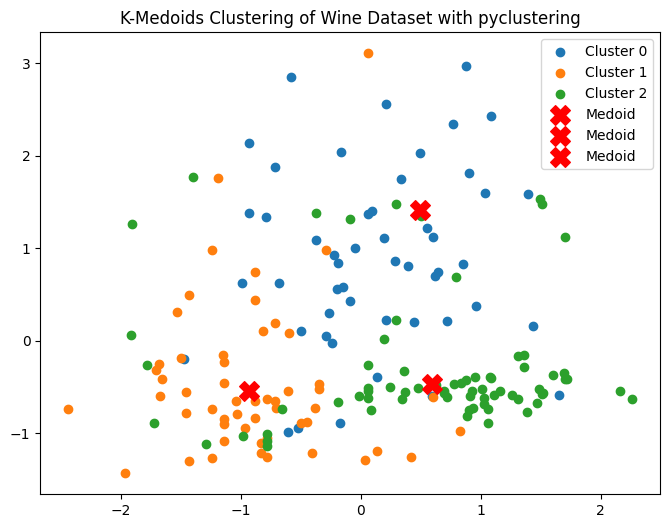

In [202]:
plt.figure(figsize=(8, 6))
for cluster in Clusters:
    plt.scatter(X_scaled[cluster, 0], X_scaled[cluster, 1], label=f'Cluster {Clusters.index(cluster)}')


for medoid in medoids:
    plt.scatter(X_scaled[medoid, 0], X_scaled[medoid, 1], s=200, c='red', label='Medoid', marker='X')

plt.title('K-Medoids Clustering of Wine Dataset with pyclustering')
plt.legend()
plt.show()